## Open the KL files and plot results

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams
import h5py
import seaborn as sns
from scipy.special import logit
from scipy.special import expit
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import entropy
from pylab import rcParams
import sys
import json

import sys
sys.path.append('../')
from populations.bbh_models import read_hdf5
import populations.bbh_models as read_models
from populations.Pop_Flows import FlowModel
from populations.utils.bounded_Nd_kde import Bounded_Nd_kde
from populations import gw_obs

In [2]:
chi_b = [0.0,0.1,0.2,0.5]
alpha_CE = [0.2,0.5,1.0,2.,5.]

In [11]:
#print values for each channels
for channel in ['CE', 'CHE', 'GC', 'NSC', 'SMT']:
    flow_KL= np.load(f'/data/{channel}_flow_KL.npy')
    kde_KL= np.load(f'/data/{channel}_KDE_KL.npy')
    print(flow_KL)
    print(kde_KL)
    print((flow_KL-kde_KL))
    print(np.mean(flow_KL-kde_KL))

[[2.39033116 4.89280845 4.61825876 4.7802486  4.37393543]
 [2.24068439 4.61409709 4.3089603  4.48378133 3.79259257]
 [2.25426681 4.41573789 4.13056983 4.35388246 3.43166231]
 [2.02718725 3.65537755 3.51103812 3.63207855 2.356694  ]]
[[2.83770484 4.88459269 4.80031523 4.96672111 4.47450452]
 [2.80790381 4.77499057 4.67295048 4.80765969 4.18875764]
 [2.79769166 4.6547636  4.55126963 4.7044855  3.91934674]
 [2.57356952 4.14182553 4.03554908 4.06102061 3.06983707]]
[[-0.44737368  0.00821576 -0.18205647 -0.18647251 -0.10056909]
 [-0.56721942 -0.16089348 -0.36399018 -0.32387836 -0.39616507]
 [-0.54342485 -0.23902571 -0.42069981 -0.35060304 -0.48768443]
 [-0.54638226 -0.48644799 -0.52451096 -0.42894206 -0.71314306]]
-0.3730633331167521
[3.72427691 3.93581987 3.71570661 0.69368455]
[4.3058951  4.31392345 3.68321027 1.73314643]
[-0.58161818 -0.37810358  0.03249634 -1.03946187]
-0.4916718227841536
[-0.55269688  1.52813075  1.98106964  2.69370404]
[1.04178986 1.86278051 2.31242096 3.0958529 ]
[-1

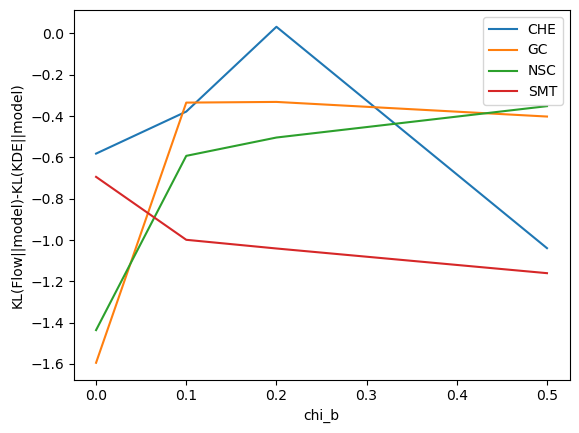

In [10]:
#plot non-CE channel values
for channel in ['CHE', 'GC', 'NSC', 'SMT']:
    flow_kde_KL= np.load(f'/data/{channel}_flow_KL.npy')
    kde_flow_KL= np.load(f'/data/{channel}_KDE_KL.npy')

    plt.plot(chi_b, (flow_kde_KL-kde_flow_KL), label=channel)
    plt.xlabel("chi_b")
    plt.ylabel("KL(Flow||model)-KL(KDE||model)")
    plt.legend()

In [46]:
#save values as JSON
for channel in ['CE', 'CHE', 'GC', 'NSC', 'SMT']:

    flow_KL= np.load(f'/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224/data/{channel}_flow_KL.npy')
    kde_KL= np.load(f'/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224/data/{channel}_KDE_KL.npy')

    if channel == 'CE':
        flow_KL_dict = dict((f'({chi_b[j]},{alpha_CE[i]})', flow_KL[j][i]) for i in range(len(alpha_CE)) for j in range(len(chi_b)))
        kde_KL_dict = dict(((f'({chi_b[j]},{alpha_CE[i]})', kde_KL[j][i]) for i in range(len(alpha_CE)) for j in range(len(chi_b))))
        
    else:
        flow_KL_dict = dict(zip(chi_b, flow_KL.T))
        kde_KL_dict = dict(zip(chi_b, kde_KL.T))
    
    channel_json = {}
    channel_json[channel] = {'flow KL':flow_KL_dict, 'KDE KL':kde_KL_dict}
    
    with open(f'KLs.json', 'a') as f:
        json.dump(channel_json, f)